In [105]:
import time
import calendar
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

import copy
import math
import torch
import torch.nn as nn

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')  # configure GPU utilization

In [106]:
df = pd.read_csv('riverlevel.csv')

In [107]:
# convert month name to integer
month_dict = dict((v, k) for k, v in enumerate(calendar.month_name))
df['Month'] = df['Month'].map(month_dict)

# create datetime column
df[['Year', 'Month', 'Day', 'Hour']] = df[['Year', 'Month', 'Day', 'Hour']].astype(int)
df['Hour'] = df['Hour'].apply(lambda x: x if x < 24 else 0)
df['Datetime'] = df[['Year', 'Month', 'Day', 'Hour']].apply(lambda row: datetime(row['Year'], row['Month'], row['Day'], row['Hour']).isoformat(), axis=1)
df["Datetime"] = pd.to_datetime(df["Datetime"], format='ISO8601')

In [108]:
df.index = df["Datetime"]
df = df.drop(['Datetime'], axis=1)

In [109]:
df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'RF-Intensity', 'RF-Intensity.1', 'Precipitation', 'Humidity', 'Temperature']]
df = df.astype(np.float64)

In [110]:
df = df.interpolate(method='linear', limit_direction='forward')
df = df.resample('24H').max()

In [111]:
df

,Waterlevel,Waterlevel.1,Waterlevel.2,RF-Intensity,RF-Intensity.1,Precipitation,Humidity,Temperature
Datetime,,,,,,,,
2012-01-01,15.94,12.53,21.97,0.0,0.0,0.08,18.01,28.69
2012-01-02,15.86,12.52,21.96,0.0,4.0,0.41,17.88,28.08
2012-01-03,15.94,12.51,21.94,7.0,4.0,1.64,17.88,27.39
2012-01-04,16.00,12.50,22.03,0.0,0.0,1.41,17.82,27.20
2012-01-05,15.85,12.49,22.01,0.0,0.0,0.35,16.36,26.10
...,...,...,...,...,...,...,...,...
2022-12-27,15.87,12.22,21.30,0.0,0.0,0.46,14.71,23.97
2022-12-28,15.87,12.19,21.30,0.0,1.0,2.95,15.81,25.87
2022-12-29,15.87,12.17,21.30,0.0,1.0,1.29,18.43,25.80


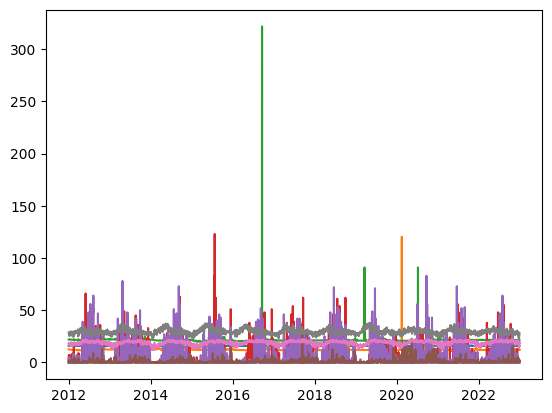

In [112]:
plt.plot(df)
plt.show()

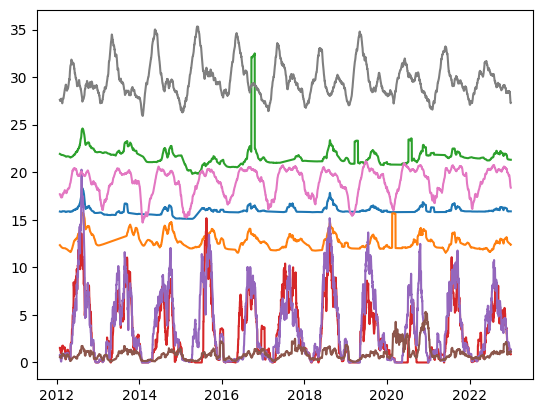

In [113]:
df = df.rolling(30).mean().dropna()

plt.plot(df)
plt.show()

In [114]:
scaler = MinMaxScaler()
scaler.fit(df)

normalized_data = scaler.transform(df)

normalized_data.shape

(3989, 8)

In [115]:
train_ds = normalized_data[:2922]
test_ds = normalized_data[-1460:]

print(train_ds.shape)
print(test_ds.shape)

(2922, 8)
(1460, 8)


In [116]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len
        
    def __getitem__(self, index):
        in_start = index
        in_end = in_start + self.seq_len
        out_start = in_end
        out_end = out_start + self.seq_len
        
        inputs = self.data[in_start:in_end]
        labels = self.data[out_start:out_end]
        
        return inputs, labels
    
    def __len__(self):
        return len(self.data) - (self.seq_len * 2) + 1

In [117]:
BATCH_SIZE = 64
SEQ_LEN = 730

train_dataset = TimeSeriesDataset(data=train_ds, seq_len=SEQ_LEN)
test_dataset = TimeSeriesDataset(data=test_ds, seq_len=SEQ_LEN)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(len(train_dataset))
print(len(test_dataset))


1463
1


In [118]:
PRED_SIZE = 8
D_MODEL = 8
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 2048
MAX_SEQ_LEN = 730 
DROPOUT = 0.10

In [119]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        
        return output
        
    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, Q, K, V):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        
        attn_output = self.scaled_dot_product_attention(Q, K, V)
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [120]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=1024):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [121]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [122]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        attn_output = self.self_attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [123]:
class Transformer(nn.Module):
    def __init__(self, pred_size, d_model, num_heads, num_layers, d_ff, dropout):
        super(Transformer, self).__init__()
        self.positional_encoding = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.fc = nn.Linear(d_model, pred_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt):
        tgt_embedded = self.dropout(self.positional_encoding(tgt))

        enc_output = tgt_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output)

        output = self.sigmoid(self.fc(enc_output))
        return output

In [124]:
encoder = Transformer(
    pred_size=PRED_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).float()

encoder.to(device)

device

device(type='cuda', index=0)

In [125]:
encoder.eval()

sample = np.reshape(test_ds[:MAX_SEQ_LEN], (1, MAX_SEQ_LEN, D_MODEL))
output = torch.from_numpy(sample).float().to(device)
output = encoder(output)
output = output.detach().cpu().numpy()

output.shape

(1, 730, 8)

In [126]:
def train_encoder(train_dataloader, val_dataloader, epochs=10, es_value=0.010):
    time_now = time.time()
    train_steps = len(train_dataloader)
    train_epochs = epochs

    model_optim = torch.optim.Adam(encoder.parameters(), lr=0.001)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(train_epochs):
        iter_count = 0
        train_loss = []

        encoder.train()
        epoch_time = time.time()
        for i, (inputs, labels) in enumerate(train_dataloader):
            iter_count += 1
            model_optim.zero_grad()
            
            batch_x = inputs.float().to(device)
            batch_y = labels.float().to(device)

            outputs = encoder(batch_x)

            loss = loss_fn(outputs, batch_y)
            train_loss.append(loss.item())

            loss.backward()
            model_optim.step()    
            
            if (i + 1) % 10 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time() 

        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        
        # evaluate model
        val_loss = []
        encoder.eval()
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(val_dataloader):
                batch_x = inputs.float().to(device)
                batch_y = labels.float()

                outputs = encoder(batch_x)
                outputs = outputs.detach().cpu()

                loss = loss_fn(outputs, batch_y)

                val_loss.append(loss)
        val_loss = np.average(val_loss)
        
        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Validation Loss: {3:.7f}".format(epoch + 1, train_steps, train_loss, val_loss))
        
        if val_loss < es_value:
            break
        
        encoder.train()
        
    torch.save(encoder.state_dict(), 'encoder.pth')  # save model

In [127]:
train_encoder(train_dataloader, test_dataloader, epochs=20, es_value=0.010)

	iters: 10, epoch: 1 | loss: 0.0588151
	speed: 1.1504s/iter; left time: 518.8305s
	iters: 20, epoch: 1 | loss: 0.0510289
	speed: 1.1287s/iter; left time: 497.7386s
Epoch: 1 cost time: 25.39613366127014
Epoch: 1, Steps: 23 | Train Loss: 0.0626019 Validation Loss: 0.0394000
	iters: 10, epoch: 2 | loss: 0.0479450
	speed: 1.4856s/iter; left time: 635.8399s
	iters: 20, epoch: 2 | loss: 0.0423756
	speed: 1.1825s/iter; left time: 494.3023s
Epoch: 2 cost time: 25.821898937225342
Epoch: 2, Steps: 23 | Train Loss: 0.0486811 Validation Loss: 0.0302627
	iters: 10, epoch: 3 | loss: 0.0402994
	speed: 1.4550s/iter; left time: 589.2824s
	iters: 20, epoch: 3 | loss: 0.0365846
	speed: 1.2560s/iter; left time: 496.1162s
Epoch: 3 cost time: 26.67976427078247
Epoch: 3, Steps: 23 | Train Loss: 0.0412548 Validation Loss: 0.0247024
	iters: 10, epoch: 4 | loss: 0.0349594
	speed: 1.5444s/iter; left time: 589.9444s
	iters: 20, epoch: 4 | loss: 0.0330602
	speed: 1.1276s/iter; left time: 419.4778s
Epoch: 4 cost ti

In [128]:
encoder.load_state_dict(torch.load('encoder.pth'))

<All keys matched successfully>

In [129]:
encoder.eval()

inputs, labels = [(inputs, labels) for _, (inputs, labels) in enumerate(test_dataloader)][0]

print(inputs.shape)
print(labels.shape)

torch.Size([1, 730, 8])
torch.Size([1, 730, 8])


In [130]:
x_test = inputs.float().to(device)

y_test = encoder(x_test)
y_test = torch.squeeze(y_test, dim=0)
y_test = y_test.detach().cpu().numpy()
y_test = y_test[-365:]
y_test = scaler.inverse_transform(y_test)

ground = torch.squeeze(labels, dim=0)
ground = ground.numpy()
ground = ground[-365:]
ground = scaler.inverse_transform(ground)

mean_absolute_error(ground, y_test)

0.826873444543053

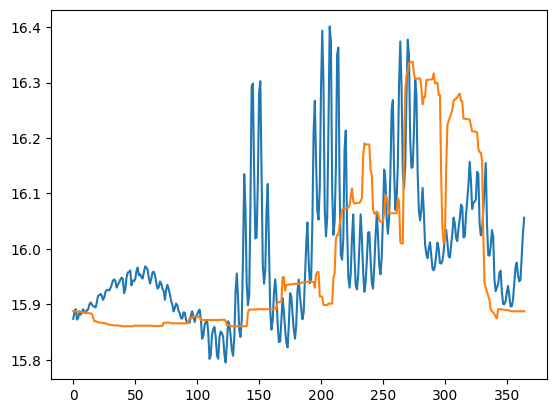

In [131]:
plt.plot(y_test[:, 0])
plt.plot(ground[:, 0])
plt.show()

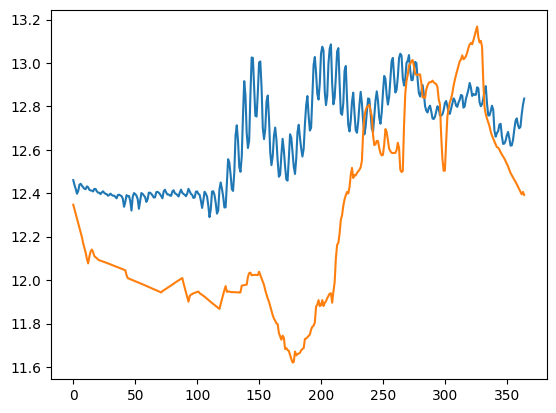

In [132]:
plt.plot(y_test[:, 1])
plt.plot(ground[:, 1])
plt.show()

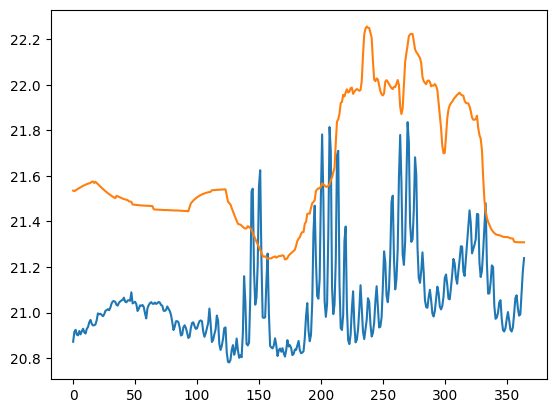

In [133]:
plt.plot(y_test[:, 2])
plt.plot(ground[:, 2])
plt.show()